### Importing Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Reading and Understanding

In [ ]:
df=pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
### checking null values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
'''
As we can see 'Glucose','BloodPressure','SkinThickness','Insulin','BMI' columns has min value as Zero
Which is not possible in any Case. Because If person any above any category is zero it means the person is dead.

We need to impute 0 with mean value.
'''

for i in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
    df[i].replace(0,np.nan,inplace=True)
    df[i].fillna(df[i].mean(),inplace=True)


In [ ]:
# checking again values
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Distribution of Output column
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

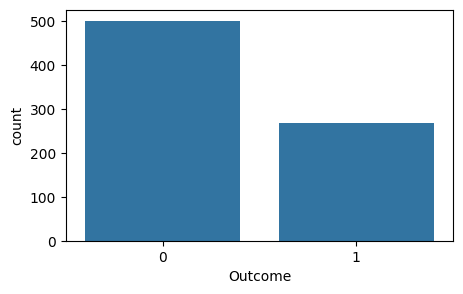

In [ ]:
plt.figure(figsize=[5,3])
sns.countplot(data = df, x = df['Outcome'])
plt.show()

In [ ]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


### Split data into X and y

In [ ]:
x = df.drop(columns = 'Outcome')
y = df['Outcome']

### splitting data into xtrain and ytrain

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=1)

#### Model

In [ ]:
# importing LogisticRegression class
from sklearn.linear_model import LogisticRegression

# create an instance
lr = LogisticRegression()

# fit
lr.fit(xtrain,ytrain)

# predict
ypred = lr.predict(xtest)

In [ ]:
ytest[:15]

285    0
101    0
581    0
352    0
726    0
472    0
233    0
385    0
556    0
59     0
756    0
341    0
445    1
614    1
371    0
Name: Outcome, dtype: int64

In [ ]:
ypred[:15]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1])

In [ ]:
predicted_df = xtest

In [ ]:
predicted_df['Actual Value'] = ytest
predicted_df['Predicted Value'] = ypred

In [ ]:
predicted_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual Value,Predicted Value
285,7,136.0,74.000000,26.00000,135.000000,26.000000,0.647,51,0,0
101,1,151.0,60.000000,29.15342,155.548223,26.100000,0.179,22,0,0
581,6,109.0,60.000000,27.00000,155.548223,25.000000,0.206,27,0,0
352,3,61.0,82.000000,28.00000,155.548223,34.400000,0.243,46,0,0
726,1,116.0,78.000000,29.00000,180.000000,36.100000,0.496,25,0,0
...,...,...,...,...,...,...,...,...,...,...
563,6,99.0,60.000000,19.00000,54.000000,26.900000,0.497,32,0,0
318,3,115.0,66.000000,39.00000,140.000000,38.100000,0.150,28,0,0
154,8,188.0,78.000000,29.15342,155.548223,47.900000,0.137,43,1,1
684,5,136.0,82.000000,29.15342,155.548223,32.457464,0.640,69,0,1


### Accuracy score

In [ ]:
# accuracy score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(ytest,ypred)

0.7922077922077922

In [ ]:
confusion_matrix(ytest,ypred)

array([[87, 12],
       [20, 35]])

### Confusion matrix(evaluation matrix)
- 1. Accuracy
- 2. Recall
- 3. Precission
- 4. FPR
- 5. F1 score

# confusion matrix

-                   Actual
-                  -v  +ve
-             -v [ TN   FN
- predicted
-             +v   FP   TP ]


Recall = positive classified by our model/Total actual positive

Recall = TP /FN + TP

Precission = positive classified by our model /Total predicted positive

= TP / FP + TP




### Terminologies used in confusion Matrix
- TP - Actual positive in the data, which have been correctly predicted as positive by our model. hence True positive
- TN - Actual Negatives in the data, which have been correctly predicted as negative as negative by our model. true negative

- FP(type 1 error) - Actual Negative in data, but our model has predicted them as positive. Hence False Positive.
- FN(type 2 error) - Actual Positive in data, but our model has predicted them as Negative. Hence False Negative.

- Accuracy - Accuracy tells the percentage of correctly prdicted values out of all the data points.

#### Formula:
- Accuracy = TP + TN / TN+FN+FP+TP

### Recall or TPR(True Positive Rate) - IMP

- Out of all the actual positive datapoints, how many have been truly identified as positive by our model.

#### Formula
- TP/TP+FN


### TNR

- Out of all the actual negatives datapoints, how many have been truly identified as negative by our model.

#### Formula
- TN/TN+FP


#### FPR (False Positive Rate) - IMP
- Out of all the negative points, how many have been falsely identified as poitive by our model.

#### Formula
- FPR: FP/TN+FP


#### FNR (False Negative Rate)
- Out of all the positive points, how many have been falsely identified as negative by our model.

#### Formula
- FNR: FN/FN+TP


#### Precision: - IMP
- Out of all the points which have been identified as positive by our model, how many are actually true.

#### Formula:
- TP/FP+TP




#### F1_score

- F1_score : combine both precision and recall scores of a model

- Formula: F1 = 2 * Precision*Recall/Precision+Recall

In [ ]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        99
           1       0.74      0.64      0.69        55

    accuracy                           0.79       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154



#### Note:

- Precision and recall are metrics used to measure model performance in machine learning. You should use precision when false positives are costly, and recall when false negatives are costly:

##### Precision
- Use when it's important to ensure that positive predictions are accurate. For example, in medical diagnosis, a false positive test can lead to unnecessary treatment, so it's better to value precision over recall.
- Example : Healthcare industry(person has diabetes but model by mistakely predicted it negative)

##### Recall
- Use when it's important to ensure that positive observations aren't missed. For example, in fraud detection, failing to detect a fraudulent transaction can result in significant financial loss, so it's better to value recall over precision.
- Example : Banking and Finance(person has not eligible for loan but model by mistakely predicted it positive)

##### F1 score
- When precision and recall are equally important, you can use the F1 score.

In [ ]:
Recall = TP /FN + TP

FN - actual positive(eligible for credit card) , model by mistake predict negative(not eligible)

Precision = TP/FP+TP

FP - actual negative(not eligible) , model by mistake predict positive(eligible for credit card)